# Bloch boundary conditions in FDTDX

This notebook shows how to use Bloch boundary conditions in [FDTDX](https://fdtdx.readthedocs.io/en/latest/). The example is a plane wave that hits a cubic simulation volume at about 45°, with a small dielectric cube in the middle as a scatterer. The four side walls are Bloch boundaries, the top and bottom are PML, and an energy detector records a video of the run. Section 2 describes the other major use of Bloch boundaries, photonic band structures.

## 1. What is a Bloch boundary?

A simulation volume is finite, so every face needs a rule for what happens to a field that reaches it. Two rules matter here. A PML absorbs the wave, which is the right choice for open space. A periodic boundary hands the field that leaves one face back in at the opposite face, so the volume acts as one tile of an infinitely repeated structure.

A periodic boundary requires $F(\mathbf r + \mathbf L) = F(\mathbf r)$. A Bloch boundary allows an additional phase:

$$
F(\mathbf{r} + \mathbf{L}) = F(\mathbf{r})\, e^{\,i\, \mathbf{k}_{\text{Bloch}} \cdot \mathbf{L}}
$$

Here $\mathbf L$ is the vector between two opposite faces and $\mathbf k_\text{Bloch}$ is a wave vector that you choose. For $\mathbf k_\text{Bloch}=0$ this is the ordinary periodic boundary.

The phase comes from Bloch's theorem. Every mode of a periodic structure can be written as a plane wave times a function $u$ that has the period of the structure:

$$
E_{n,\mathbf k}(\mathbf r) = u_{n,\mathbf k}(\mathbf r)\, e^{i \mathbf k \cdot \mathbf r}, \qquad u_{n,\mathbf k}(\mathbf r + \mathbf L) = u_{n,\mathbf k}(\mathbf r).
$$

Shifting by one period leaves $u$ unchanged but multiplies the plane wave by $e^{i\mathbf k\cdot\mathbf L}$. That is the relation the boundary enforces.

### Tilted plane waves

The case we need here is a plane wave that hits a periodic structure at an angle. Such a wave has a nonzero in-plane wave vector $\mathbf k_\parallel$, so its phase advances by $\mathbf k_\parallel\cdot\mathbf L$ from one period to the next and the field is not periodic. A plain periodic boundary would reset the phase at every edge, which shows up as spurious scattering at the side walls. With $\mathbf k_\text{Bloch}=\mathbf k_\parallel$ the boundary applies the phase the wave actually has, and the volume behaves like one cell cut out of an infinitely wide tilted wave.

## 2. Bloch boundaries and band structures

The tilted-wave example below uses a single frequency and a single Bloch vector. Bloch boundaries are also the standard tool for computing the band structure $\omega_n(\mathbf k)$ of a periodic structure such as a photonic crystal. The procedure is:

1. Model one unit cell, with Bloch boundaries along every periodic direction and PML (or another open boundary) along the others. This is the same kind of setup as in this notebook.
2. Excite the cell with a broadband source, for example a short pulse or a few point dipoles at random positions, so that many modes are excited at once.
3. Record the field over time at one or a few points inside the cell.
4. Fourier transform the signal (or use harmonic inversion). Every mode that exists at this $\mathbf k$ appears as a sharp peak, and the position of the peak is an eigenfrequency $\omega_n(\mathbf k)$.
5. Repeat for $\mathbf k_\text{Bloch}$ along the edges of the irreducible Brillouin zone. For a 2D square lattice this path is $\Gamma \to X \to M \to \Gamma$.
6. Plot all extracted frequencies against $\mathbf k$ to get the band diagram.

The tilted-wave example uses the same `fdtdx.BlochBoundary`. The only difference is that the Bloch vector is set by the angle of the source and not by a sweep through the Brillouin zone.

## 3. Building the simulation

### 3.1 Imports

In [1]:
import time

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Video

import fdtdx
from fdtdx.core.linalg import get_wave_vector_raw, rotate_vector

%matplotlib inline

### 3.2 Config and volume

The wavelength is 1.55 µm, the grid spacing is 100 nm, and the volume is a cube with 5.5 µm side length. The 5.5 µm is chosen together with the angle, see section 3.3.

In [4]:
key = jax.random.PRNGKey(42)
object_list = []

wavelength = 1.55e-6  # free-space wavelength

config = fdtdx.SimulationConfig(
    time=60e-15,
    grid=fdtdx.UniformGrid(spacing=100e-9),
    dtype=jnp.float32,
    courant_factor=0.99,
)

L = 5.5e-6  # cubic volume, same side length along x, y and z
volume = fdtdx.SimulationVolume(
    partial_real_shape=(L, L, L),
    material=fdtdx.Material(  # background material (vacuum)
        permittivity=1.0,
        permeability=1.0,
    ),
)
object_list.append(volume)

constraints = []

### 3.3 Which angles are allowed

A Bloch boundary does not work for every angle in a given cell. The reason is that the FDTDX plane source is real valued. For a wave tilted in the xz-plane it injects $\cos(k_x x + k_z z - \omega t)$, and this is the sum of two complex waves, one proportional to $e^{+ik_x x}$ and one proportional to $e^{-ik_x x}$. We set $k_{\text{Bloch},x} = +k_x$, so the boundary is only consistent with the first one. The second wave picks up the phase $e^{+ik_xL}$ at the boundary where it would need $e^{-ik_xL}$. Both agree only if

$$
e^{+ik_xL} = e^{-ik_xL} \iff k_x L = m\pi, \quad m \in \mathbb Z .
$$

With $k_x = \frac{2\pi}{\lambda}\sin\theta$ this means

$$
\sin\theta = \frac{m\lambda}{2L}.
$$

If the condition holds, the Bloch phase is $e^{ik_xL} = (-1)^m$ and the whole real wave fits the boundary. If it does not, the mismatched half turns into a second wave that travels in the mirrored direction. In the video it shows up as a cross-hatched pattern and a diagonal seam instead of clean fringes.

For $L = 6\,\mu\text{m}$ and 45° we would have $k_xL = 5.47\pi$, which is not allowed (the closest allowed angles are 40.2° and 50.8°). With $L = 5.5\,\mu\text{m}$ the choice $m=5$ gives 44.8°, which is close enough to 45°. The next cell picks the allowed angle that is closest to the target.

In [7]:
target_angle_deg = 45.0

# k_x * L has to be a multiple of pi, i.e. sin(theta) = m * wavelength / (2 * L)
m = round(2 * L * np.sin(np.deg2rad(target_angle_deg)) / wavelength)
angle_of_incidence_deg = float(np.rad2deg(np.arcsin(m * wavelength / (2 * L))))  # measured from the z-axis
print(f"m = {m}, angle of incidence = {angle_of_incidence_deg:.2f} deg")

m = 5, angle of incidence = 44.79 deg


### 3.4 Bloch vector from the source angle

The source is tilted with an `azimuth_angle` and an `elevation_angle`. These are not the usual spherical angles. For a source in the xy-plane (`horizontal_axis = x`, `vertical_axis = y`, `propagation_axis = z`), `azimuth_angle` alone tilts the propagation direction within the xz-plane, `elevation_angle` alone tilts it within the yz-plane, and using both does not compose like yaw and pitch. We keep `elevation_angle = 0` and only use the azimuth, so the wave is tilted within the xz-plane.

To get the Bloch vector we rotate the unit vector of a downward-travelling wave with the same function the source uses internally. This way the Bloch vector always matches what the source injects.

In [10]:
theta = np.deg2rad(angle_of_incidence_deg)

propagation_axis = 2  # z: the source lies in the xy-plane
horizontal_axis, vertical_axis = 0, 1  # x, y

wave_vector_raw = get_wave_vector_raw(
    direction="-",              # propagating downward, -z
    propagation_axis=propagation_axis,
    dtype=jnp.float32,
)
wave_vector_dir = rotate_vector(
    wave_vector_raw,
    azimuth_angle=theta,     # angle of incidence
    elevation_angle=0.0,     # keep the tilt in the x-z plane
    axes_tuple=(horizontal_axis, vertical_axis, propagation_axis),
)
wave_vector_dir = np.asarray(wave_vector_dir)
print("unit propagation direction (x, y, z):", np.round(wave_vector_dir, 4))

k0 = 2 * np.pi / wavelength  # free-space wavenumber (background index n = 1)
bloch_vector = tuple(k0 * wave_vector_dir)
print("Bloch vector (kx, ky, kz) [rad/m]:", bloch_vector)
print("kx * L / pi =", round(float(bloch_vector[0]) * L / np.pi, 4))  # should be an integer, see 3.3

unit propagation direction (x, y, z): [-0.7045  0.     -0.7097]
Bloch vector (kx, ky, kz) [rad/m]: (np.float32(-2.8559932e+06), np.float32(0.0), np.float32(-2.8767218e+06))
kx * L / pi = -5.0


Only the x and y components are used, because those are the faces with a Bloch boundary. The z faces are PML, and a `BlochBoundary` only reads the vector component along its own axis.

### 3.5 Boundaries: Bloch on the sides, PML on top and bottom

`fdtdx.BoundaryConfig.from_uniform_bound` sets one boundary type on all six faces and lets us override single faces. We use `"bloch"` everywhere and override `min_z` and `max_z` with `"pml"`. The PML layers are 10 cells (1 µm) thick. A Bloch boundary is always one cell thick.

In [14]:
bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(
    thickness=10,
    boundary_type="bloch",
    override_types={"min_z": "pml", "max_z": "pml"},
    bloch_vector=bloch_vector,
)
bound_dict, c_list = fdtdx.boundary_objects_from_config(bound_cfg, volume)
object_list.extend(bound_dict.values())
constraints.extend(c_list)


### 3.6 The tilted plane-wave source

A `UniformPlaneSource` is a plane wave with constant amplitude (a `GaussianPlaneSource` would have a finite spot size). It spans the whole xy-plane and uses the same angle as the Bloch vector. We put it directly below the top PML, 1.25 µm from the top of the volume, so that the wave does not start inside the absorbing layer.

In [17]:
source = fdtdx.UniformPlaneSource(
    partial_grid_shape=(None, None, 1),     # one cell thick
    fixed_E_polarization_vector=(1, 0, 0),  # Ex-polarized
    wave_character=fdtdx.WaveCharacter(wavelength=wavelength),
    direction="-",                          # propagating downward
    azimuth_angle=angle_of_incidence_deg,   # tilted within the x-z plane
    elevation_angle=0.0,
)
object_list.append(source)
constraints.extend(
    [
        source.place_relative_to(
            volume,
            axes=(0, 1, 2),
            own_positions=(0, 0, 1),
            other_positions=(0, 0, 1),
            margins=(0, 0, -1.25e-6),  # directly below the 1 um thick top PML
        ),
        source.same_size(volume, axes=(0, 1)),  # spans the full xy plane
    ]
)

### 3.7 A small scatterer

In empty space the video would only show a tilted wave moving through the volume. A small dielectric cube ($\varepsilon = 4$, so $n = 2$) in the middle adds some scattering to look at.

In [20]:
cube = fdtdx.UniformMaterialObject(
    partial_real_shape=(1.5e-6, 1.5e-6, 1.5e-6),
    material=fdtdx.Material(permittivity=4.0),  # n ~ 2, e.g. a dielectric like Si3N4/TiO2
    name="Cube",
    color=fdtdx.colors.PINK,
)
object_list.append(cube)
constraints.append(cube.place_at_center(volume))


### 3.8 The video detector

An `EnergyDetector` with `as_slices=True` stores the field energy on three slices through the volume at regular intervals (here every fourth time step). `draw_plot()` turns these slices into a video later on.

In [23]:
video_energy_detector = fdtdx.EnergyDetector(
    name="Video",
    as_slices=True,
    switch=fdtdx.OnOffSwitch(interval=4),  # record every 4th time step
    exact_interpolation=True,
    num_video_workers=4,
)
object_list.append(video_energy_detector)
constraints.extend(video_energy_detector.same_position_and_size(volume))


### 3.9 Placing the objects

`fdtdx.place_objects` turns all constraints into concrete grid positions.

In [26]:
key, subkey = jax.random.split(key)
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list=object_list,
    config=config,
    constraints=constraints,
    key=subkey,
)

print("field dtype (should be complex since the Bloch vector != 0):", arrays.fields.E.dtype)
print("grid shape (x, y, z):", arrays.fields.E.shape[1:])


field dtype (should be complex since the Bloch vector != 0): complex64
grid shape (x, y, z): (55, 55, 55)


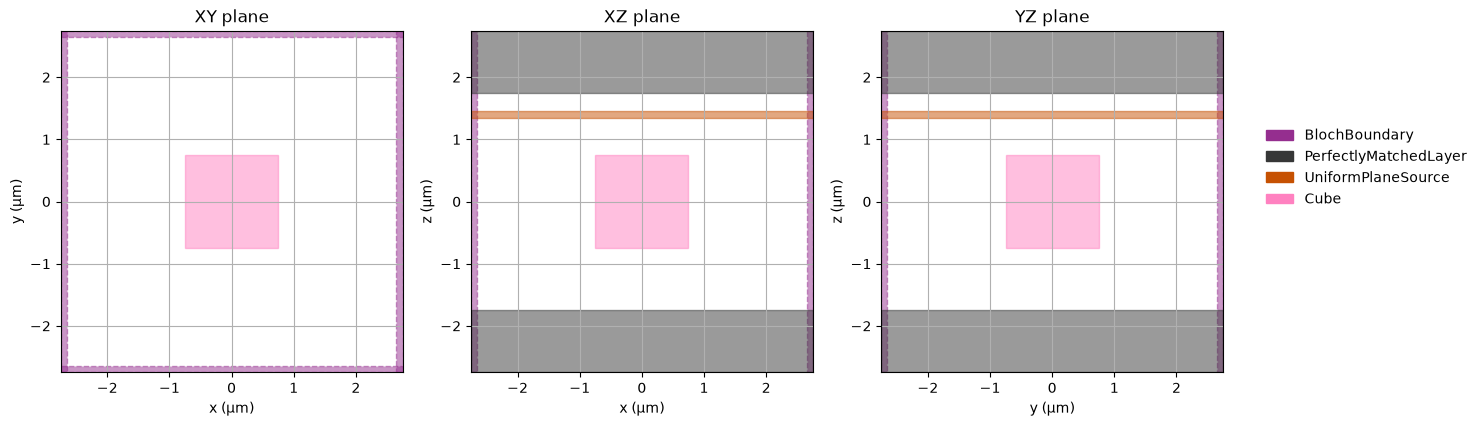

In [27]:
fig = fdtdx.plot_setup(
    config=config,
    objects=objects,
    exclude_object_list=[video_energy_detector],
)
plt.show()


### 3.10 Running the simulation

As usual in FDTDX, `apply_params` and `run_fdtd` are wrapped into one function that is compiled with `jax.jit`.

In [31]:
def sim_fn(params, arrays, key):
    arrays, new_objects, _ = fdtdx.apply_params(arrays, objects, params, key)
    final_state = fdtdx.run_fdtd(
        arrays=arrays,
        objects=new_objects,
        config=config,
        key=key,
    )
    _, arrays = final_state
    return arrays


start_time = time.time()
jitted_sim_fn = jax.jit(sim_fn).lower(params, arrays, key).compile()
end_time = time.time()
print(f"Compilation time: {end_time - start_time:.2f} s")


Compilation time: 0.43 s


In [33]:
start_time = time.time()
new_arrays = jitted_sim_fn(params, arrays, subkey)
end_time = time.time()
print(f"Simulation runtime: {end_time - start_time:.2f} s")


FDTD (checkpointed):   0%|                            | 0/315 [00:00<?, ?step/s]

Simulation runtime: 0.50 s


## 4. Result

`draw_plot` renders the recorded slices as a video. A few things to look for:

- The wave does not appear everywhere at once. It starts in the upper right and spreads to the left, so the front of the wave is a diagonal line. This is expected. The source ramps up over four periods, and the time delay that tilts the wave also applies to this ramp, so cells further left start a little later. Once the ramp is over the diagonal is gone.
- When the wave has filled the volume, the fringes in the xz-slice run through the left and right walls without a seam. This is what the Bloch boundary is for.
- The plotted quantity is the field energy at one instant, not a time average, so the fringes move with the wave.

If you change the size of the volume or the angle such that $k_xL$ is no longer a multiple of $\pi$ (for example 45° with $L = 6\,\mu\text{m}$), you will see a second set of fringes in the mirrored direction, mostly in the lower right of the xz-slice.

In [36]:
video_path = objects["Video"].draw_plot(new_arrays.detector_states["Video"])
print(video_path)
Video(list(video_path.values())[0], embed=True, width=720)


{'sliced_video': '/var/folders/9c/sf1_5nb17v51rk1l8xcxshdc0000gn/T/tmpwqtyte3g.mp4'}
